# Лабораторна робота № 1. Дослідження процесів дискретизації, квантування сигналів та ефекту аліасингу

### Мета: Дослідити фундаментальні закономірності перетворення неперервних аналогових сигналів у дискретну та цифрову форми, експериментально перевірити теорему відліків Котельникова-Шеннона-Найквіста, вивчити природу виникнення стробоскопічного ефекту (аліасингу) в часовій та спектральній областях, а також опанувати методи розрахунку похибок квантування за рівнем, оцінки співвідношення сигнал/шум (SNR) та застосування алгоритмів дизеризації для лінеаризації характеристик квантування. 

#### *Варіант 2 (№ 22 у списку: $22 - 20 = 2$)*

### <div align="right">Виконав: Яцентюк Євгеній, група: КІ-24-1</div>
<div align="right">
  <a href="https://github.com/kefir4ikk"><b>GitHub</b></a>
</div>




## 1. Імпорт бібліотек та налаштування стилю відображення

In [4]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)
os.makedirs("data", exist_ok=True)

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['grid.color'] = '#cccccc'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.alpha'] = 0.6

## 2. Параметри варіанта 2 та аналітичний розрахунок

$s(t)=A_1\sin(2\pi f_1 t)+A_2\cos(2\pi f_2 t+\varphi)$, $A_1=3$ В, $f_1=150$ Гц, $A_2=2$ В, $f_2=800$ Гц, $\varphi=\pi/4$, $f_{s3}=950$ Гц.

$f_{max}=800$ Гц → $f_{s1}=3200$ Гц, $f_{s2}=1600$ Гц. Хибна частота: $f_{alias}=|f_0-k f_s|=|800-950|=150$ Гц.

In [6]:
# варіанта 2
A1, f1 = 3.0, 150.0
A2, f2 = 2.0, 800.0
phi = np.pi / 4
fs3 = 950.0                 # частота піддискретизації з таблиці
f_alias_expected = 150.0    # очікувана хибна частота з таблиці
f_max = max(f1, f2)         # 800 Гц

fs1 = 4 * f_max             # 3200 Гц
fs2 = 2 * f_max             # 1600 Гц
f_nyq3 = fs3 / 2

def s(t):
    return A1 * np.sin(2 * np.pi * f1 * t) + A2 * np.cos(2 * np.pi * f2 * t + phi)

# Аналітичний розрахунок аліасингу
k = int(np.floor(f2 / fs3 + 0.5))
f_alias = abs(f2 - k * fs3)
print(f"f_max = {f_max} Гц; fs1 = {fs1}, fs2 = {fs2}, fs3 = {fs3} Гц")
print(f"f_Nyq(fs3) = {f_nyq3} Гц; k = {k}; f_alias = |{f2} - {k}*{fs3}| = {f_alias} Гц (таблиця: {f_alias_expected})")

f_max = 800.0 Гц; fs1 = 3200.0, fs2 = 1600.0, fs3 = 950.0 Гц
f_Nyq(fs3) = 475.0 Гц; k = 1; f_alias = |800.0 - 1*950.0| = 150.0 Гц (таблиця: 150.0)


## 3. Дискретизація та спектральний аналіз (ШПФ)

Дискретизуємо сигнал при $f_{s1}, f_{s2}, f_{s3}$ та будуємо односторонні амплітудні спектри (`rfft`, з коректною нормуванням постійної складової та частоти Найквіста).

fs1 піки спектра: [(150.0, 3.0), (800.0, 2.0)]
fs2 піки спектра: [(150.0, 3.0), (800.0, 1.414)]
fs3 піки спектра: [(150.0, 4.635)]


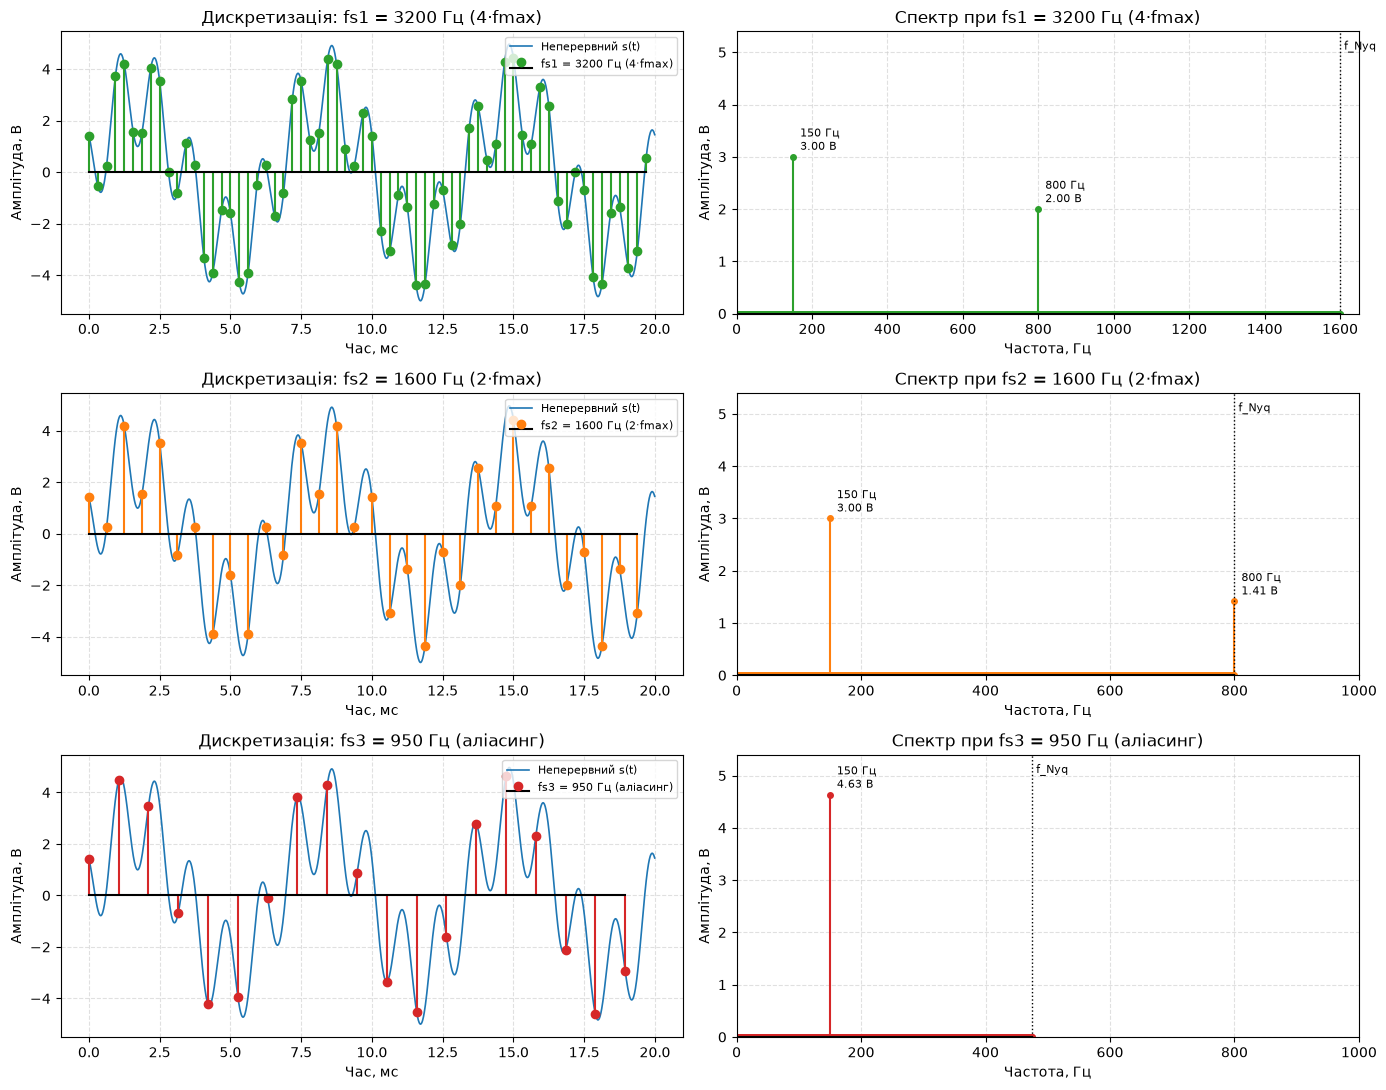

In [7]:
fs_cont = 100000.0
T_obs = 0.02
t_cont = np.arange(0, T_obs, 1 / fs_cont)
s_cont = s(t_cont)

def sample(fs, T):
    t = np.arange(0, T, 1 / fs)
    return t, s(t)

def spectrum(x, fs):
    """Однобічний амплітудний спектр (rfft) з коректною нормуванням DC і Найквіста."""
    N = len(x)
    X = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(N, 1 / fs)
    amp = 2.0 / N * np.abs(X)
    amp[0] /= 2.0
    if N % 2 == 0:
        amp[-1] /= 2.0
    return freqs, amp

T_long = 1.0  # 1 с -> роздільність 1 Гц
spectra = {}
for name, fs in [("fs1", fs1), ("fs2", fs2), ("fs3", fs3)]:
    _, xl = sample(fs, T_long)
    spectra[name] = spectrum(xl, fs)

def peaks(fr, am, thr=0.05):
    return [(float(f), round(float(a), 3)) for f, a in zip(fr, am) if a > thr]

for name in spectra:
    print(name, "піки спектра:", peaks(*spectra[name]))

colors = {'fs1': '#2ca02c', 'fs2': '#ff7f0e', 'fs3': '#d62728'}
labels = {'fs1': f'fs1 = {fs1:.0f} Гц (4·fmax)', 'fs2': f'fs2 = {fs2:.0f} Гц (2·fmax)', 'fs3': f'fs3 = {fs3:.0f} Гц (аліасинг)'}
fsd = {'fs1': fs1, 'fs2': fs2, 'fs3': fs3}

fig, axes = plt.subplots(3, 2, figsize=(14, 11))
for i, name in enumerate(['fs1', 'fs2', 'fs3']):
    t_s, s_s = sample(fsd[name], T_obs)
    ax = axes[i, 0]
    ax.plot(t_cont * 1000, s_cont, color='#1f77b4', lw=1.2, label='Неперервний s(t)')
    ml, sl, bl = ax.stem(t_s * 1000, s_s, linefmt=colors[name], markerfmt='o', basefmt='k-', label=labels[name])
    plt.setp(ml, color=colors[name]); plt.setp(sl, color=colors[name])
    ax.set_title(f"Дискретизація: {labels[name]}")
    ax.set_xlabel("Час, мс"); ax.set_ylabel("Амплітуда, В")
    ax.grid(True); ax.legend(loc='upper right', fontsize=8)

    fr, am = spectra[name]
    ax = axes[i, 1]
    ml, sl, bl = ax.stem(fr, am, linefmt=colors[name], markerfmt='o', basefmt='k-')
    plt.setp(ml, color=colors[name], markersize=4); plt.setp(sl, color=colors[name])
    ax.set_xlim(0, max(fsd[name] / 2 + 50, 1000))
    ax.set_ylim(0, 5.4)
    ax.axvline(fsd[name] / 2, color='k', ls=':', lw=1)
    ax.text(fsd[name] / 2, 5.05, ' f_Nyq', fontsize=8)
    ax.set_title(f"Спектр при {labels[name]}")
    ax.set_xlabel("Частота, Гц"); ax.set_ylabel("Амплітуда, В")
    ax.grid(True)
    for f_, a_ in peaks(fr, am):
        ax.annotate(f"{f_:.0f} Гц\n{a_:.2f} В", (f_, a_), textcoords='offset points', xytext=(5, 5), fontsize=8)
plt.tight_layout()
plt.savefig("figures/sampling_aliasing.png", dpi=200)
plt.show()

## 4. Квантування за рівнем, похибки та SNR

$\Delta=(V_{max}-V_{min})/(2^N-1)$, $\sigma_e^2=\Delta^2/12$, $SNR=10\lg(P_s/P_e)$. Діапазон АЦП $[-5;+5]$ В, бо $\max|s(t)|\le A_1+A_2=5$ В.


--- КВАНТУВАННЯ ---
N= 2 | L=    4 | Δ=3.333333 В | σ²теор=9.259e-01 | σ²практ=8.742e-01 | SNR=8.71 дБ | SNR_теор=13.80 дБ
N= 4 | L=   16 | Δ=0.666667 В | σ²теор=3.704e-02 | σ²практ=3.485e-02 | SNR=22.71 дБ | SNR_теор=25.84 дБ
N= 8 | L=  256 | Δ=0.039216 В | σ²теор=1.282e-04 | σ²практ=1.363e-04 | SNR=46.79 дБ | SNR_теор=49.92 дБ
N=16 | L=65536 | Δ=0.000153 В | σ²теор=1.940e-09 | σ²практ=2.769e-09 | SNR=93.71 дБ | SNR_теор=98.08 дБ


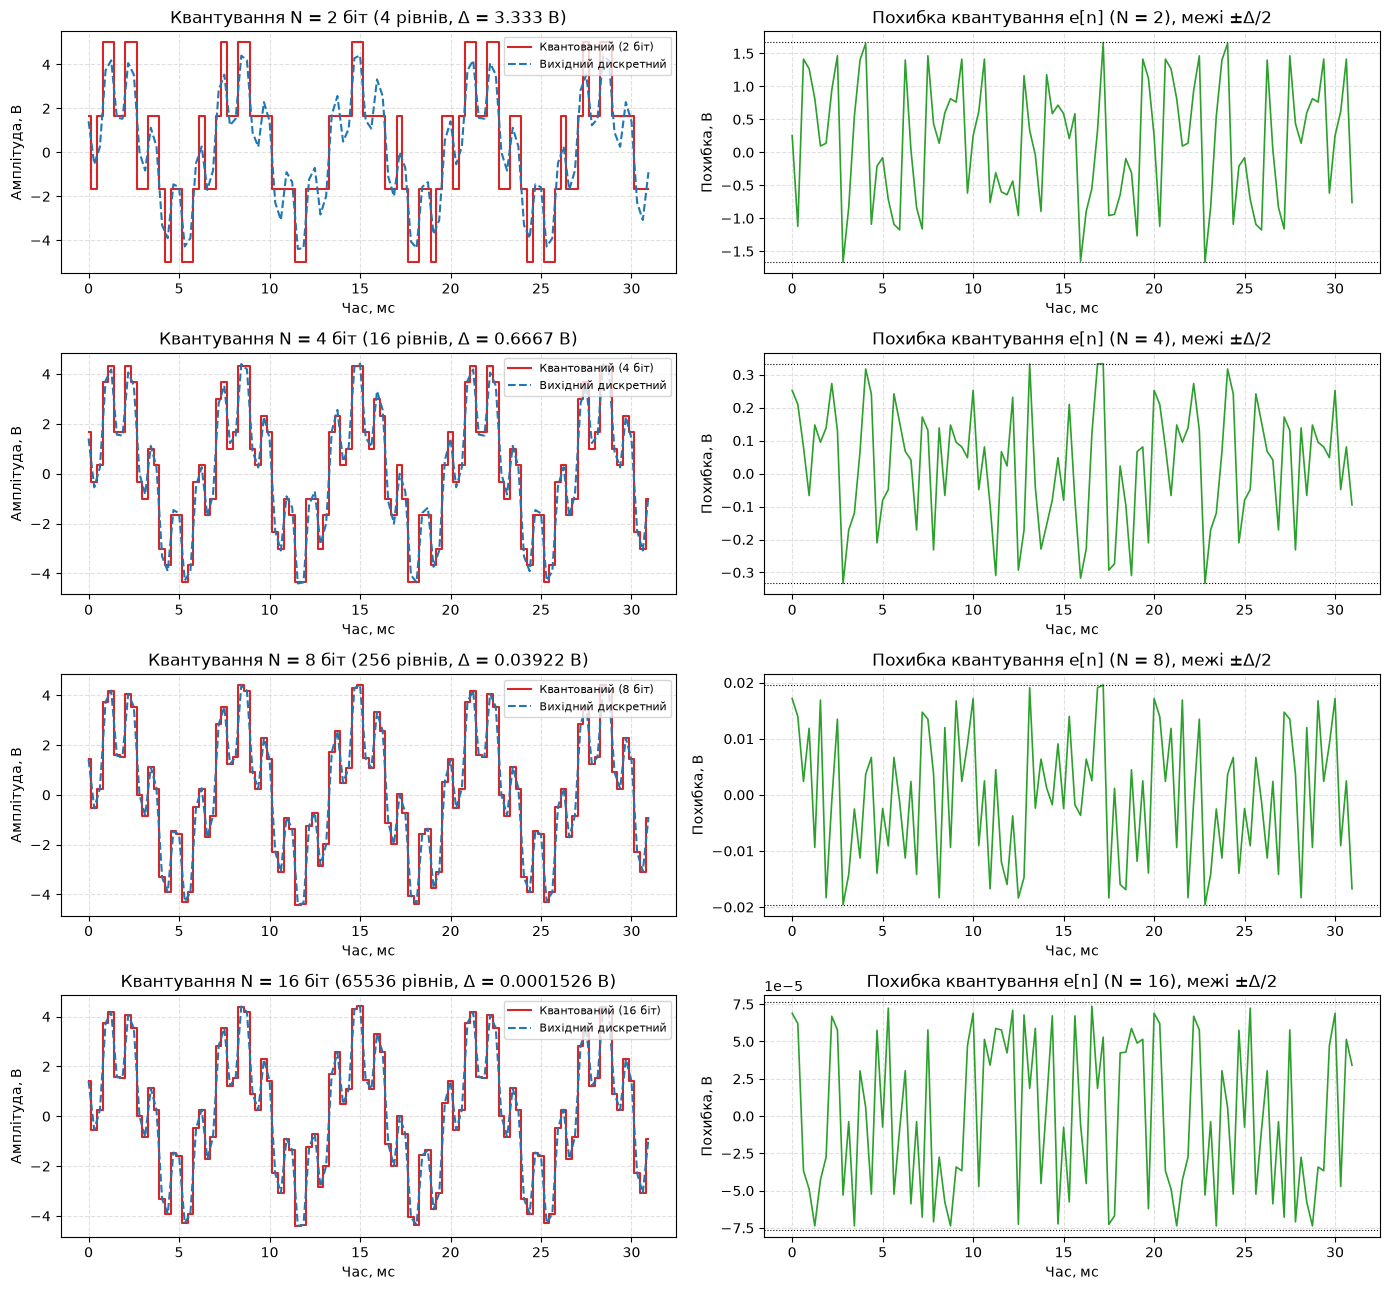

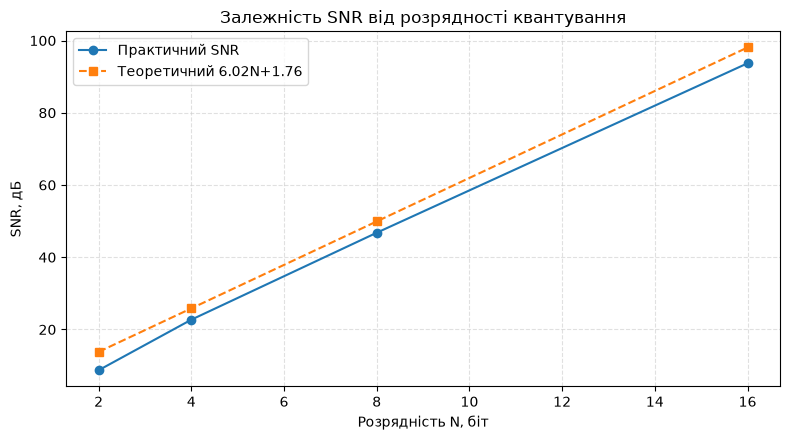

In [15]:
V = A1 + A2            # 5 В: сигнал не виходить за діапазон
v_min, v_max = -V, V

def uniform_quantize(x, bits, vmin, vmax):
    L = 2 ** bits
    delta = (vmax - vmin) / (L - 1)
    idx = np.clip(np.round((x - vmin) / delta), 0, L - 1)
    xq = vmin + idx * delta
    return xq, xq - x, delta

def snr_db(x, e):
    pn = np.mean(e ** 2)
    return np.inf if pn == 0 else 10 * np.log10(np.mean(x ** 2) / pn)

t_l1, x_l1 = sample(fs1, T_long)
bit_depths = [2, 4, 8, 16]
results = []
print("\n--- КВАНТУВАННЯ ---")
for b in bit_depths:
    xq, e, d = uniform_quantize(x_l1, b, v_min, v_max)
    r = dict(bits=b, levels=2 ** b, delta=float(d), var_theor=float(d ** 2 / 12),
             var_pract=float(np.mean(e ** 2)), snr=float(snr_db(x_l1, e)),
             snr_theor=6.02 * b + 1.76, emax=float(np.max(np.abs(e))))
    results.append(r)
    print(f"N={b:2d} | L={2**b:5d} | Δ={d:.6f} В | σ²теор={r['var_theor']:.3e} | σ²практ={r['var_pract']:.3e} | "
          f"SNR={r['snr']:.2f} дБ | SNR_теор={r['snr_theor']:.2f} дБ")

n_show = 100
t_show = t_l1[:n_show] * 1000
fig, axes = plt.subplots(4, 2, figsize=(14, 13))
for i, b in enumerate(bit_depths):
    xq, e, d = uniform_quantize(x_l1[:n_show], b, v_min, v_max)
    axes[i, 0].step(t_show, xq, where='mid', color='#d62728', label=f'Квантований ({b} біт)')
    axes[i, 0].plot(t_show, x_l1[:n_show], '--', color='#1f77b4', label='Вихідний дискретний')
    axes[i, 0].set_title(f"Квантування N = {b} біт ({2**b} рівнів, Δ = {d:.4g} В)")
    axes[i, 0].set_xlabel("Час, мс"); axes[i, 0].set_ylabel("Амплітуда, В")
    axes[i, 0].grid(True); axes[i, 0].legend(fontsize=8, loc='upper right')
    axes[i, 1].plot(t_show, e, color='#2ca02c', lw=1.2)
    axes[i, 1].axhline(d / 2, color='k', ls=':', lw=0.8); axes[i, 1].axhline(-d / 2, color='k', ls=':', lw=0.8)
    axes[i, 1].set_title(f"Похибка квантування e[n] (N = {b}), межі ±Δ/2")
    axes[i, 1].set_xlabel("Час, мс"); axes[i, 1].set_ylabel("Похибка, В")
    axes[i, 1].grid(True)
plt.tight_layout()
plt.savefig("figures/quantization_error.png", dpi=200)
plt.show()

# SNR vs N
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(bit_depths, [r['snr'] for r in results], 'o-', label='Практичний SNR')
ax.plot(bit_depths, [r['snr_theor'] for r in results], 's--', label='Теоретичний 6.02N+1.76')
ax.set_xlabel("Розрядність N, біт"); ax.set_ylabel("SNR, дБ"); ax.grid(True); ax.legend()
ax.set_title("Залежність SNR від розрядності квантування")
plt.tight_layout(); plt.savefig("figures/snr_vs_bits.png", dpi=200); plt.show()

## 5. Дизеризація (dithering)

$N=3$ біти, дизер-шум $d[n]\sim U(-A_d,A_d)$, $A_d=0{,}5\Delta$. Порівнюємо спектри похибки квантування.


Дизеризація N=3: Δ=1.4286 В, A_d=0.7143 В; SNR без = 14.58 дБ, з = 12.39 дБ
Макс. пік спектра похибки без дизеру: -10.2 дБВ, з дизером: -23.4 дБВ
Середній рівень спектра похибки без: -118.1 дБВ, з: -35.7 дБВ


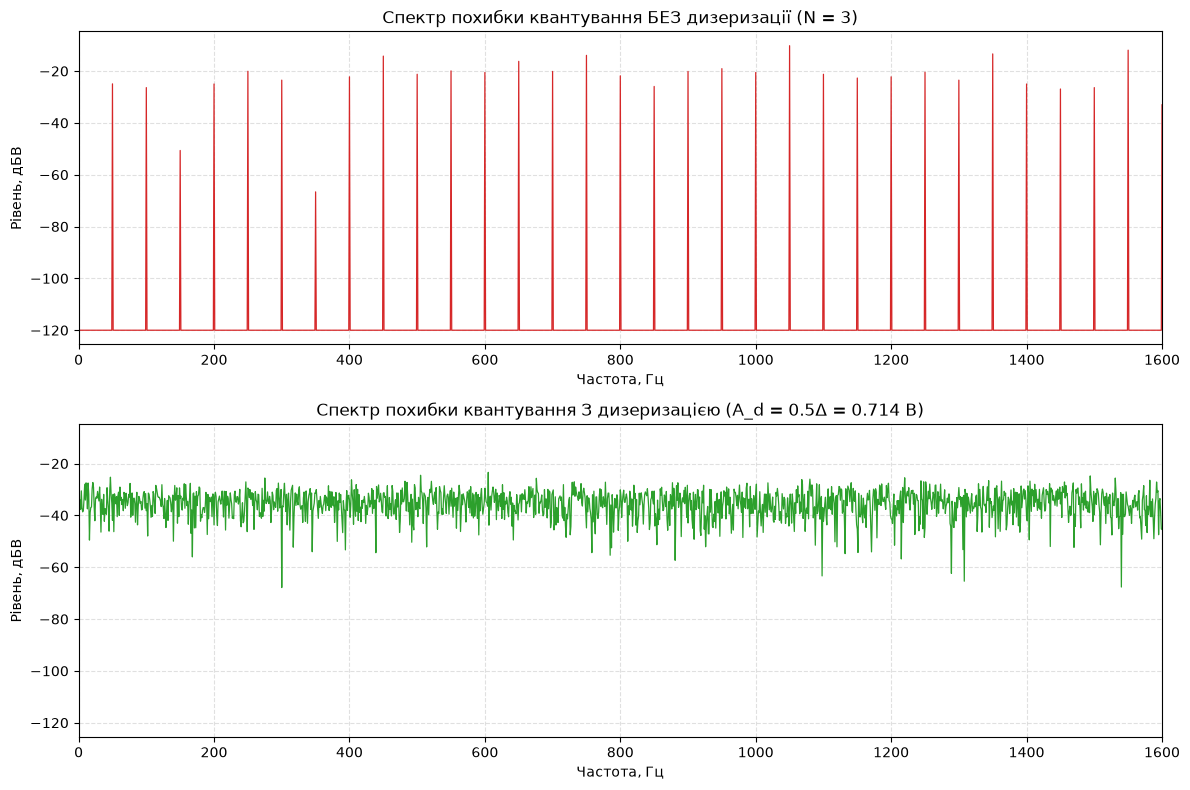

In [12]:
np.random.seed(42)
bits_d = 3
_, _, delta_d = uniform_quantize(x_l1, bits_d, v_min, v_max)
Ad = 0.5 * delta_d
q_nod, e_nod, _ = uniform_quantize(x_l1, bits_d, v_min, v_max)
dither = np.random.uniform(-Ad, Ad, size=len(x_l1))
q_dit, _, _ = uniform_quantize(x_l1 + dither, bits_d, v_min, v_max)
e_dit = q_dit - x_l1

snr_nod, snr_dit = snr_db(x_l1, e_nod), snr_db(x_l1, e_dit)
print(f"\nДизеризація N={bits_d}: Δ={delta_d:.4f} В, A_d={Ad:.4f} В; SNR без = {snr_nod:.2f} дБ, з = {snr_dit:.2f} дБ")

f_e1, a_e1 = spectrum(e_nod, fs1)
f_e2, a_e2 = spectrum(e_dit, fs1)
db = lambda a: 20 * np.log10(np.maximum(a, 1e-6))
print("Макс. пік спектра похибки без дизеру: %.1f дБВ, з дизером: %.1f дБВ" % (db(a_e1[1:]).max(), db(a_e2[1:]).max()))
print("Середній рівень спектра похибки без: %.1f дБВ, з: %.1f дБВ" % (db(a_e1[1:]).mean(), db(a_e2[1:]).mean()))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharey=True)
axes[0].plot(f_e1, db(a_e1), color='#d62728', lw=0.9)
axes[0].set_title(f"Спектр похибки квантування БЕЗ дизеризації (N = {bits_d})")
axes[1].plot(f_e2, db(a_e2), color='#2ca02c', lw=0.9)
axes[1].set_title(f"Спектр похибки квантування З дизеризацією (A_d = 0.5Δ = {Ad:.3f} В)")
for ax in axes:
    ax.set_xlabel("Частота, Гц"); ax.set_ylabel("Рівень, дБВ")
    ax.set_xlim(0, fs1 / 2); ax.grid(True)
plt.tight_layout(); plt.savefig("figures/dither_spectrum.png", dpi=200); plt.show()

## 6. Експорт результатів

In [16]:
np.savetxt("data/output_signals.csv",
           np.column_stack([t_l1, x_l1, q_nod, q_dit]),
           delimiter=",", header="t_s,x_fs1,x_q_nodither_3bit,x_q_dither_3bit", comments="")
json.dump(dict(results=results, snr_nod=snr_nod, snr_dit=snr_dit, delta_d=delta_d, Ad=Ad,
               f_alias=f_alias,
               peaks={k_: peaks(*v) for k_, v in spectra.items()},
               max_nod=float(db(a_e1[1:]).max()), max_dit=float(db(a_e2[1:]).max())),
          open("data/results.json", "w"), ensure_ascii=False, indent=1)
print("\nГотово: figures/, data/")


Готово: figures/, data/


## Висновки

1. При $f_{s1}=4f_{max}$ спектр містить обидві гармоніки (150 Гц — 3 В; 800 Гц — 2 В). При критичній $f_{s2}=2f_{max}$ амплітуда 800 Гц стає 1,41 В ($=A_2\cos\varphi$), тому на практиці $f_s$ беруть із запасом.
2. При $f_{s3}=950$ Гц гармоніка 800 Гц відображається на $|800-950|=150$ Гц і накладається на $f_1$: у спектрі один пік 4,64 В замість 3 В, вихідний сигнал відновити неможливо.
3. +1 біт ≈ +6 дБ SNR; практичні значення на 3–5 дБ нижчі за $6{,}02N+1{,}76$, бо двогармонічний сигнал має меншу потужність, ніж повномасштабна синусоїда.
4. Дизеризація перетворює дискретні гармоніки похибки на шумоподібний спектр (максимальний пік −10,2 → −23,4 дБВ), але загальний SNR трохи знижується (14,58 → 12,39 дБ).